# Belebele: English/Ukrainian data review

Inspect paired reading-comprehension questions and prepare utility evaluation. Each item has a passage, a question, four options, and one correct answer.

Source: [Belebele](https://huggingface.co/datasets/facebook/belebele), CC BY-SA 4.0. [Dataset documentation](https://github.com/facebookresearch/belebele).

In [1]:
from pathlib import Path
import hashlib
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
revision = "7899cdfa4e1e0d733fd77c848e2c273cb1d32be2"
folder = root / "data" / "belebele" / revision
folder.mkdir(parents=True, exist_ok=True)
expected_hashes = {
    "eng_Latn": "15af884c2b5994fdc71199e79d553a1864b08ce1b31894aa87f6be925a064a31",
    "ukr_Cyrl": "a064f157a9322a8bf76f3027da353fe85dbe79e5e5b86aa39b131246d9add932",
}
frames = {}
for language in ["eng_Latn", "ukr_Cyrl"]:
    path = folder / f"{language}.jsonl"
    if not path.exists():
        url = f"https://huggingface.co/datasets/facebook/belebele/resolve/{revision}/data/{language}.jsonl"
        urllib.request.urlretrieve(url, path)
    assert hashlib.sha256(path.read_bytes()).hexdigest() == expected_hashes[language]
    frames[language] = (
        pd.read_json(path, lines=True)
        .sort_values(["link", "question_number"])
        .reset_index(drop=True)
    )
    print(
        language, len(frames[language]), hashlib.sha256(path.read_bytes()).hexdigest()
    )
en, uk = frames["eng_Latn"], frames["ukr_Cyrl"]
pd.set_option("display.max_colwidth", None)

eng_Latn 900 15af884c2b5994fdc71199e79d553a1864b08ce1b31894aa87f6be925a064a31
ukr_Cyrl 900 a064f157a9322a8bf76f3027da353fe85dbe79e5e5b86aa39b131246d9add932


## Schema

`correct_answer_num` uses 1-4, matching `mc_answer1` through `mc_answer4`. `dialect` identifies the language. `ds` differs between language exports; it is not used as a cross-language pairing key.

In [2]:
display(en.dtypes.to_frame("dtype"))
display(
    pd.DataFrame({language: frame.isna().sum() for language, frame in frames.items()})
)
display(
    pd.DataFrame(
        {language: frame.ds.value_counts() for language, frame in frames.items()}
    )
    .fillna(0)
    .astype(int)
)

,dtype
link,object
question_number,int64
flores_passage,object
question,object
mc_answer1,object
mc_answer2,object
mc_answer3,object
mc_answer4,object
correct_answer_num,int64
dialect,object


,eng_Latn,ukr_Cyrl
link,0,0
question_number,0,0
flores_passage,0,0
question,0,0
mc_answer1,0,0
mc_answer2,0,0
mc_answer3,0,0
mc_answer4,0,0
correct_answer_num,0,0
dialect,0,0


,eng_Latn,ukr_Cyrl
ds,,
2023-05-03,900,0
2023-07-21,0,900


## Coverage and pairing
Pair on `(link, question_number)`. Verify uniqueness, coverage, and matching answer positions.

In [3]:
keys = ["link", "question_number"]
for language, frame in frames.items():
    assert not frame.duplicated(keys).any()
    assert frame.correct_answer_num.isin([1, 2, 3, 4]).all()
    assert frame.dialect.eq(language).all()
paired = en.merge(
    uk,
    on=keys,
    suffixes=("_en", "_uk"),
    how="outer",
    indicator=True,
    validate="one_to_one",
)
display(paired._merge.value_counts().to_frame("items"))
assert paired._merge.eq("both").all()
print(
    "Answer-position mismatches:",
    paired.correct_answer_num_en.ne(paired.correct_answer_num_uk).sum(),
)
assert paired.correct_answer_num_en.eq(paired.correct_answer_num_uk).all()
display(
    pd.DataFrame(
        {
            language: {
                "questions": len(frame),
                "passages": frame.link.nunique(),
                "exact_repeated_questions": frame.question.duplicated().sum(),
            }
            for language, frame in frames.items()
        }
    )
)

,items
_merge,
both,900
left_only,0
right_only,0


Answer-position mismatches: 0


,eng_Latn,ukr_Cyrl
questions,900,900
passages,488,488
exact_repeated_questions,0,0


## Random paired examples
Two question IDs, both languages. Answer positions are shown for data inspection.

In [4]:
example_ids = en[keys].sample(n=2, random_state=42)
text_columns = [
    "flores_passage",
    "question",
    "mc_answer1",
    "mc_answer2",
    "mc_answer3",
    "mc_answer4",
    "correct_answer_num",
]
for item in example_ids.itertuples(index=False):
    print(item.link, "question", item.question_number)
    for language, frame in frames.items():
        row = frame[
            (frame.link == item.link) & (frame.question_number == item.question_number)
        ]
        print(language)
        display(row[text_columns].T.rename(columns={row.index[0]: "text"}))

https://en.wikibooks.org/wiki/Fundamentals_of_Transportation/Traffic_Flow question 1
eng_Latn


,text
flores_passage,"Traffic Flow is the study of the movement of individual drivers and vehicles between two points and the interactions they make with one another. Unfortunately, studying traffic flow is difficult because driver behavior cannot be predicted with one-hundred percent certainty. Fortunately, drivers tend to behave within a reasonably consistent range; thus, traffic streams tend to have some reasonable consistency and can be roughly represented mathematically. To better represent traffic flow, relationships have been established between the three main characteristics: (1) flow, (2) density, and (3) velocity. These relationships help in planning, design, and operations of roadway facilities."
question,"According to the passage, which of the following can be difficult to gauge due to the unpredictability of drivers?"
mc_answer1,Traffic velocity
mc_answer2,Roadway planning
mc_answer3,Roadway operations
mc_answer4,Traffic Flow
correct_answer_num,4


ukr_Cyrl


,text
flores_passage,"Дорожній потік – це визначення руху окремих водіїв і транспортних засобів між двома точками, а також їхньої взаємодії. На жаль, вивчати транспортні потоки складно, оскільки поведінку водія неможливо передбачити зі стовідсотковою точністю. На щастя, водії зазвичай поводять себе досить узгоджено; таким чином, потоки транспорту здебільшого мають деяку логічну послідовність, і можуть мати приблизну математичну модель. Щоб краще представити потік транспорту, відносини було встановлено між трьома основними характеристиками: (1) потік, (2) щільність і (3) швидкість. Ці співвідношення допомагають при плануванні, проектуванні та забезпеченні функціонування доріг."
question,"Згідно з уривком, що з наведеного нижче важко виміряти через непередбачуваність водіїв?"
mc_answer1,Швидкість руху
mc_answer2,Планування проїжджої частини
mc_answer3,Експлуатацію доріг
mc_answer4,Транспортний потік
correct_answer_num,4


https://en.wikivoyage.org/wiki/South_Asian_cuisine question 1
eng_Latn


,text
flores_passage,"""A curry is a dish based on herbs and spices, together with either meat or vegetables. A curry can be either """"dry"""" or """"wet"""" depending on the amount of liquid. In inland regions of Northern India and Pakistan, yogurt is commonly used in curries; in Southern India and some other coastal regions of the subcontinent, coconut milk is commonly used."""
question,"According to the passage, a curry is based around which ingredients?"
mc_answer1,Yogurt and water
mc_answer2,Herbs and spices
mc_answer3,Coconut milk and meat
mc_answer4,Vegetables and milk
correct_answer_num,2


ukr_Cyrl


,text
flores_passage,"""Карі — це страва, що складається з трав і спецій, поєднаних з м'ясом або овочами. Карі може бути """"сухим"""" або """"вологим"""" залежно від кількості рідини. У внутрішніх районах Північної Індії та Пакистану у карі традиційно додають йогурт; у Південній Індії та подекуди в інших узбережних районах субконтиненту традиційно додають кокосове молоко."""
question,"Згідно з уривком, з яких інгредієнтів складається карі?"
mc_answer1,Йогурт та вода
mc_answer2,Трави і спеції
mc_answer3,Кокосове молоко та м'ясо
mc_answer4,Овочі та молоко
correct_answer_num,2


## Answer positions and passage reuse

,eng_Latn,ukr_Cyrl
correct_answer_num,,
1,206,206
2,251,251
3,246,246
4,197,197


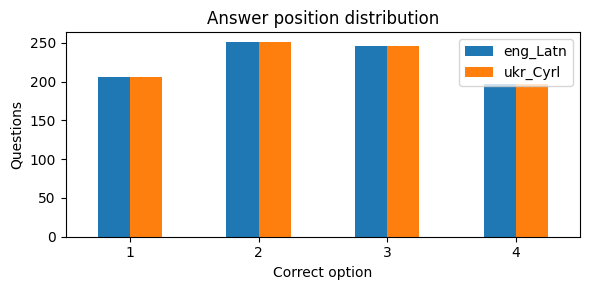

,passages
questions_per_passage,
1,76
2,412


In [5]:
answer_counts = pd.DataFrame(
    {
        language: frame.correct_answer_num.value_counts().sort_index()
        for language, frame in frames.items()
    }
)
display(answer_counts)
ax = answer_counts.plot.bar(figsize=(6, 3), rot=0)
ax.set(
    xlabel="Correct option", ylabel="Questions", title="Answer position distribution"
)
plt.tight_layout()
plt.show()
display(
    en.groupby("link")
    .size()
    .value_counts()
    .sort_index()
    .to_frame("passages")
    .rename_axis("questions_per_passage")
)

## Blank text and repeated options

In [6]:
fields = [
    "flores_passage",
    "question",
    "mc_answer1",
    "mc_answer2",
    "mc_answer3",
    "mc_answer4",
]
blank_counts = pd.DataFrame(
    {
        language: frame[fields].apply(lambda column: column.str.strip().eq("").sum())
        for language, frame in frames.items()
    }
)
display(blank_counts)
option_columns = ["mc_answer1", "mc_answer2", "mc_answer3", "mc_answer4"]
for language, frame in frames.items():
    repeated_options = frame[option_columns].nunique(axis=1).lt(4)
    print(language, "items with identical option text:", repeated_options.sum())
    display(frame.loc[repeated_options, keys + option_columns])

,eng_Latn,ukr_Cyrl
flores_passage,0,0
question,0,0
mc_answer1,0,0
mc_answer2,0,0
mc_answer3,0,0
mc_answer4,0,0


eng_Latn items with identical option text: 2


,link,question_number,mc_answer1,mc_answer2,mc_answer3,mc_answer4
401,https://en.wikinews.org/wiki/German_judge_orders_life_sentence_for_nation%27s_%27first_Islamic-motivated_terror_attack%27,1,4,2,5,2
779,https://en.wikivoyage.org/wiki/Maori_culture,2,Gas,Hot stones,Geothermal heat,Hot stones


ukr_Cyrl items with identical option text: 2


,link,question_number,mc_answer1,mc_answer2,mc_answer3,mc_answer4
401,https://en.wikinews.org/wiki/German_judge_orders_life_sentence_for_nation%27s_%27first_Islamic-motivated_terror_attack%27,1,4,2,5,2
779,https://en.wikivoyage.org/wiki/Maori_culture,2,Газ,Гаряче каміння,Геотермальне тепло,Гаряче каміння


## Lengths
Whitespace-separated words. Token lengths will be measured with the model tokenizer.

,English passage,Ukrainian passage,English question,Ukrainian question
count,900.0,900.0,900.0,900.0
mean,79.1,69.4,12.9,10.4
std,26.2,23.4,4.0,3.5
min,23.0,21.0,3.0,3.0
50%,77.0,68.0,13.0,10.0
95%,122.0,107.0,19.0,16.0
max,217.0,196.0,28.0,23.0


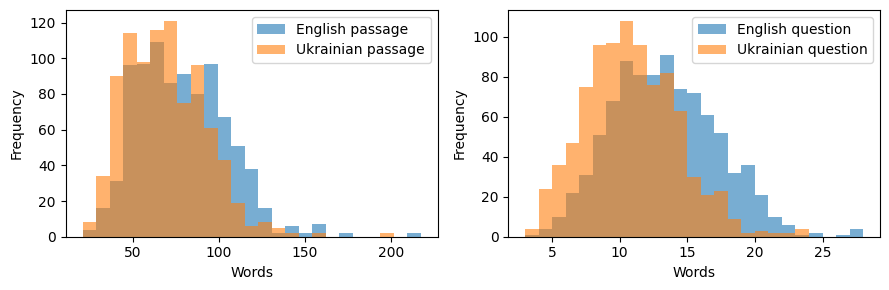

In [7]:
lengths = pd.DataFrame(
    {
        "English passage": en.flores_passage.str.split().str.len(),
        "Ukrainian passage": uk.flores_passage.str.split().str.len(),
        "English question": en.question.str.split().str.len(),
        "Ukrainian question": uk.question.str.split().str.len(),
    }
)
display(lengths.describe(percentiles=[0.5, 0.95]).round(1))
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
lengths[["English passage", "Ukrainian passage"]].plot.hist(
    bins=25, alpha=0.6, ax=axes[0]
)
lengths[["English question", "Ukrainian question"]].plot.hist(
    bins=25, alpha=0.6, ax=axes[1]
)
for ax in axes:
    ax.set_xlabel("Words")
plt.tight_layout()
plt.show()

## Longest passage: paired records

In [8]:
longest = en.loc[en.flores_passage.str.split().str.len().idxmax()]
for language, frame in frames.items():
    print(language)
    row = frame[
        (frame.link == longest.link)
        & (frame.question_number == longest.question_number)
    ]
    display(row[keys + text_columns].T)

eng_Latn


,738
link,https://en.wikivoyage.org/wiki/Greenland
question_number,1
flores_passage,"""Thanks to undersea fiber optic cable links to Europe and broadband satellite, Greenland is well connected with 93% of the population having internet access. Your hotel or hosts (if staying in a guesthouse or private home) will likely have wifi or an internet connected PC, and all settlements have an internet cafe or some location with public wifi. As mentioned above, though the word """"Eskimo"""" remains acceptable in the United States, it is considered pejorative by many non-U.S. Arctic peoples, especially in Canada. While you may hear the word used by Greenlandic Natives, its use should be avoided by foreigners. The native inhabitants of Greenland call themselves Inuit in Canada and Kalaalleq (plural Kalaallit), a Greenlander, in Greenland. Crime, and ill-will toward foreigners in general, is virtually unknown in Greenland. Even in the towns, there are no """"rough areas."""" Cold weather is perhaps the only real danger the unprepared will face. If you visit Greenland during cold seasons (considering that the further north you go, the colder it will be), it is essential to bring warm enough clothing. The very long days in the summer can lead to problems getting sufficient sleep and associated health issues. During the summer, also watch out for the Nordic mosquitoes. Although they do not transmit any diseases, they can be irritating."""
question,"According to the passage, what should be avoided by travelers visiting Greenland?"
mc_answer1,Certain areas that are known for high crime rates
mc_answer2,"Bringing heavy clothing, as the climate is generally warm year-round"
mc_answer3,"Expecting to work while there, as internet connection can be spotty"
mc_answer4,Referring to a native of Greenland as an “Eskimo”
correct_answer_num,4


ukr_Cyrl


,738
link,https://en.wikivoyage.org/wiki/Greenland
question_number,1
flores_passage,"""Завдяки підводним волоконно-оптичним кабельним лініям зв'язку з Європою і широкосмуговому супутниковому телебаченню, Гренландія має гарний зв'язок 93% населення, що має доступ до Інтернету. У вашому готелі або у господаря (якщо ви зупиняєтесь в гостьовому будинку або у приватної особи) швидше за все буде Wi-Fi або комп'ютер із Інтернетом, і всі поселення мають інтернет-салон або місця з безкоштовним Wi-Fi. Як згадувалося вище, хоча слово """"ескімос"""" залишається прийнятним в США, проте, багато арктичних народів за межами США, особливо в Канаді, вважають його зневажливим. Це слово можна почути з вуст корінного гренландського населення, проте самим його вживати не варто. Корінні жителі Гренландії називають себе інуїтами в Канаді та калаалек (множина калааліт), тобто гренландець, у Гренландії. Злочинність і недоброзичливе ставлення до іноземців в цілому в Гренландії фактично незнані. Навіть у містах немає """"темних районів"""". Холодна погода – напевно, єдина реальна небезпека для непідготовлених мандрівників. Якщо ви відвідуєте Гренландію в холодну пору року (чим далі ви рухаєтеся на північ, то холодніша температура на вас чекає), необхідно взяти із собою теплий одяг. Дуже довгі дні влітку можуть призвести до проблем зі сном і відповідних труднощів зі здоров'ям. Влітку також стежте за скандинавськими комарами. Хоча вони не передають ніяких хвороб, вони можуть дратувати."""
question,"Згідно з уривком, чого слід уникати мандрівникам, які відвідують Гренландію?"
mc_answer1,"Певних районів, відомих високим рівнем злочинності"
mc_answer2,"Приносити важкий одяг, оскільки клімат, переважно, є теплим протягом року"
mc_answer3,"Сподіватися працювати, перебуваючи там, оскільки підключення до Інтернету може бути нестабільним"
mc_answer4,"""Називати корінного мешканця Гренландії """"ескімосом"""""""
correct_answer_num,4


## Evaluation prompt

Zero-shot, English instructions in both languages. Passage, question, and options remain in their original language. No answer key enters the prompt.

In [9]:
def make_prompt(row):
    options = "\n".join(
        f"{letter}. {row[f'mc_answer{number}']}"
        for number, letter in enumerate("ABCD", start=1)
    )
    return (
        "Read the passage and answer the question. Choose the correct option. "
        "Reply with only A, B, C, or D.\n\n"
        f"Passage:\n{row['flores_passage']}\n\n"
        f"Question: {row['question']}\n{options}"
    )


for language, frame in frames.items():
    print(language)
    print(make_prompt(frame.iloc[0]))
    print()

eng_Latn
Read the passage and answer the question. Choose the correct option. Reply with only A, B, C, or D.

Passage:
Make sure your hand is as relaxed as possible while still hitting all the notes correctly - also try not to make much extraneous motion with your fingers. This way, you will tire yourself out as little as possible. Remember there's no need to hit the keys with a lot of force for extra volume like on the piano. On the accordion, to get extra volume, you use the bellows with more pressure or speed.

Question: According to the passage, what would not be considered an accurate tip for successfully playing the accordion?
A. For additional volume, increase the force with which you hit the keys
B. Keep unnecessary movement to a minimum in order to preserve your stamina
C. Be mindful of hitting the notes while maintaining a relaxed hand
D. Increase the speed with which you operate the bellows to achieve extra volume

ukr_Cyrl
Read the passage and answer the question. Choose th

## Scoring

Choose the highest-scoring answer label among A-D. Accuracy is correct predictions divided by evaluated items; uniform guessing has expected accuracy 25%. Compare identical question IDs across languages, models, and interventions.

The benchmark is a test set, not extraction or tuning data. A short runtime check is reported separately from the full 900-item evaluation. [Official evaluation settings](https://github.com/facebookresearch/belebele#pausible-evaluation-settings).